# Quantum Adiabatic Pulses

Here we prepare a ground state of a Hamiltonian using an adiabatic pulse. See [...] for theory

Recall the Rydberg Hamiltonian is

$$
H = \frac{\hbar \Omega}{2} \sum_i  X_i - \hbar \delta \sum_i  N_i + \sum_{i<j} \frac{C_6}{r_{ij}^6}N_i N_j 
$$

where 
- $\Omega$ is the Rabi frequency, which may be time dependent
- $\delta$ is the detuning, which may be time dependent
- $C_6$ is a device specific constant
- $r_{ij}$ is the distance between qubits $i$ and $j$

Or in terms of the Blockade radius (for a Rabi frequency of $\Omega'$ )see [...]

$$
\frac{H}{\hbar\Omega'} = \frac{\Omega}{2 \Omega'} \sum_i  X_i - \frac{\delta}{\Omega'} \sum_i  N_i + \sum_{i<j} \frac{1}{(r_{ij}/r_b)^6}N_i N_j 
$$


We will choose a chain geometry with a lattice spacing of $r_b$ so that 

$$\sum_{i<j} \frac{1}{(r_{ij}/r_b)^6}N_i N_j =\sum_{i<j} \frac{1}{|i-j|^6}N_i N_j \approx \sum_{i=1}^{N-1} N_i N_{i+1}$$

We will choose the signals so that the initial Hamiltonian will be

$$
H_i = - \frac{\delta}{\Omega'} \sum_i  N_i + \sum_{i<j} \frac{1}{(r_{ij}/r_b)^6}N_i N_j 
$$

and the final Hamiltonian

$$
H_f = \frac{\Omega}{2 \Omega'} \sum_i  X_i + \sum_{i<j} \frac{1}{(r_{ij}/r_b)^6}N_i N_j 
$$



In [1]:
import qse
import matplotlib.pyplot as plt
import numpy as np

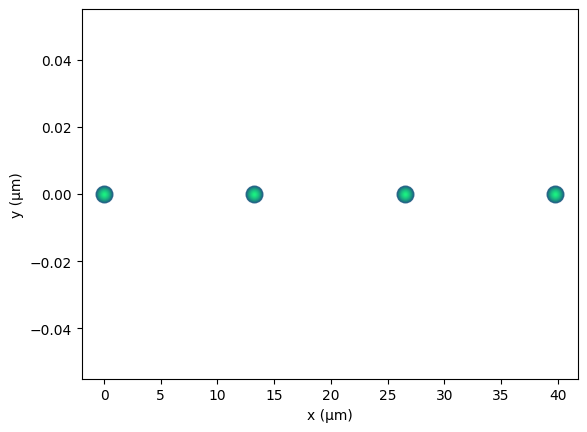

In [2]:
omega_f = 1.0
r_b = qse.calc.blockade_radius(omega_f)
qbits = qse.lattices.chain(r_b, 4)
qbits.draw(equal_aspect=False, units="µm")

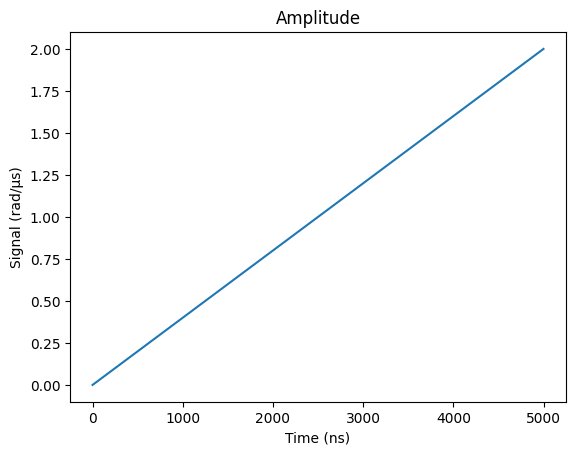

In [48]:
duration = 5000
amplitude = qse.Signal(np.linspace(0, 2 * omega_f, duration))
fig = amplitude.draw("ns", "rad/µs", "Amplitude")

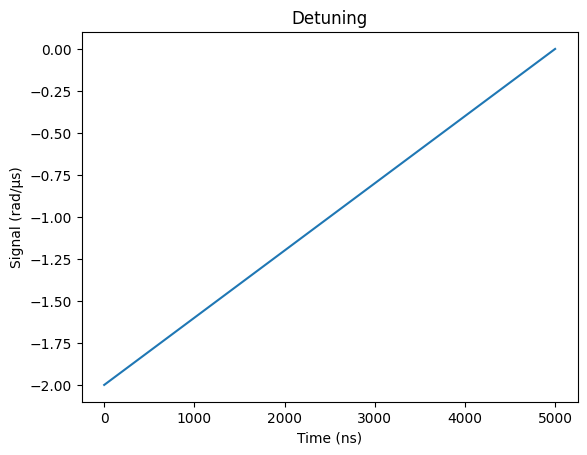

In [81]:
detuning = qse.Signal(np.linspace(-2.0, 0, duration))
fig = detuning.draw("ns", "rad/µs", "Detuning")

In [82]:
calc = qse.calc.Qutip(qbits, amplitude, detuning)

h_i = calc.get_hamiltonian(amplitude[0], detuning[0])
h_f = calc.get_hamiltonian(amplitude[-1], detuning[-1])

In [83]:
e_i = h_i.eigenenergies()[0]
e_f = h_f.eigenenergies()[0]
e_f, e_i

(np.float64(-3.501077891650598), np.float64(0.0))

In [84]:
results = calc.calculate([h_i, h_f])

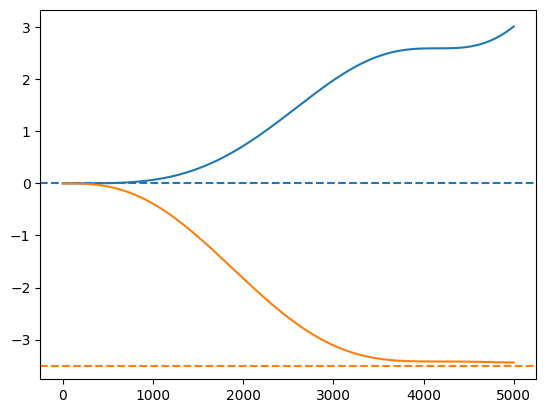

In [85]:
plt.plot(results["expectations"][:, 0])
plt.axhline(e_i, ls="--")

plt.plot(results["expectations"][:, 1])
plt.axhline(e_f, ls="--", c="C1")
plt.show()

In [63]:
probs = np.real(np.conj(results["state"]) * results["state"]).flatten()
probs_dict = {f"{np.binary_repr(c, qbits.nqbits)}": p for c, p in enumerate(probs)}
probs_dict = {
    w: probs_dict[w] for w in sorted(probs_dict, key=probs_dict.get, reverse=True)
}

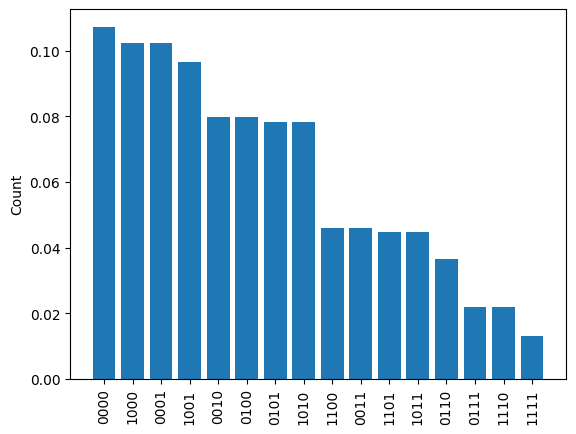

In [64]:
fig = qse.vis.bar(probs_dict)